## [LangGraph](https://huggingface.co/learn/agents-course/ko/unit2/langgraph/introduction)

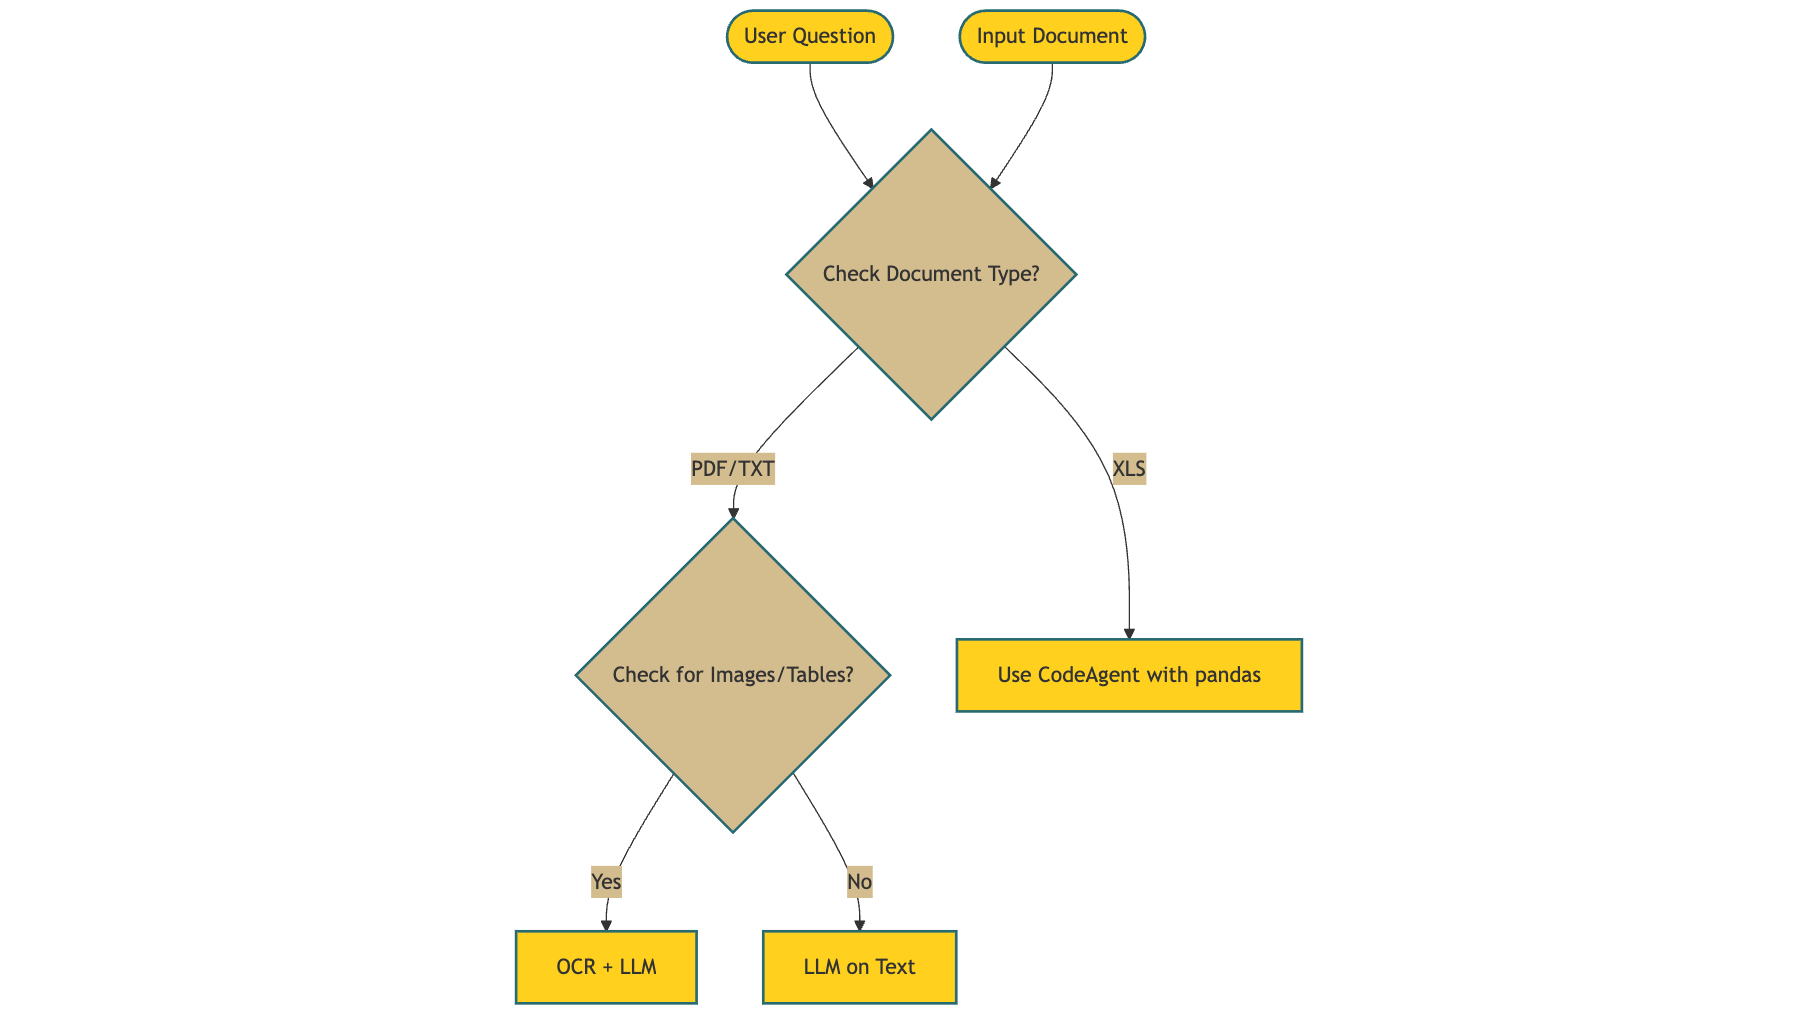

`LangGraph가 유용한 경우:`

- 명시적인 흐름 제어가 필요한 다단계 논리적 추론 프로세스
- 단계 간 상태 지속이 필요한 어플리케이션
- 결정론적 로직과 AI 기능을 결합하는 시스템
- 사람의 개입이 필요한 워크플로우
- 여러 구성 요소가 함께 작동하는 복잡한 에이전트 아키텍처  
  
요약하자면, 최대한 사람이 직접 각 단계의 출력에 따라 실행할 다음 단계를 설계해야 하는 경우, LangGraph가 가장 적절합니다!

`LangGraph는 어떻게 작동하나요?`  
LangGraph는 어플리케이션의 흐름을 정의하기 위해 방향성 그래프 구조를 사용합니다:

- 노드(Node)는 각 처리 단계를 나타냅니다(LLM 호출, 도구 사용, 의사결정 등).
- 엣지(Edge)는 단계 간 가능한 전환을 정의합니다.
- 상태(State)는 사용자가 정의하고 유지하며 실행 중 노드 간에 전달됩니다. 다음에 어떤 노드를 실행할지 결정할 때, 현재 상태가 기준입니다.  
  
이러한 기본 구성 요소들은 다음 장에서 더 자세히 살펴보겠습니다!

`일반 파이썬과 어떻게 다른가요? 왜 LangGraph가 필요한가요?`  
“그냥 일반 파이썬 문법으로 if-else 문 쓰면 되지 않나요?”라고 궁금해할 수 있습니다.  
  
기술적으로는 가능하지만, LangGraph는 복잡한 시스템 구축을 위해 일반 파이썬보다 여러 가지 장점을 제공합니다. LangGraph 없이도 동일한 어플리케이션을 구축할 수 있지만, LangGraph는 더 쉽게 개발할 수 있는 도구와 추상화를 제공합니다.  

예: 상태 관리, 시각화, 로깅(트레이스), 내장형 사용자 개입 처리 기능 등.  

### [Components](https://huggingface.co/learn/agents-course/ko/unit2/langgraph/building_blocks)

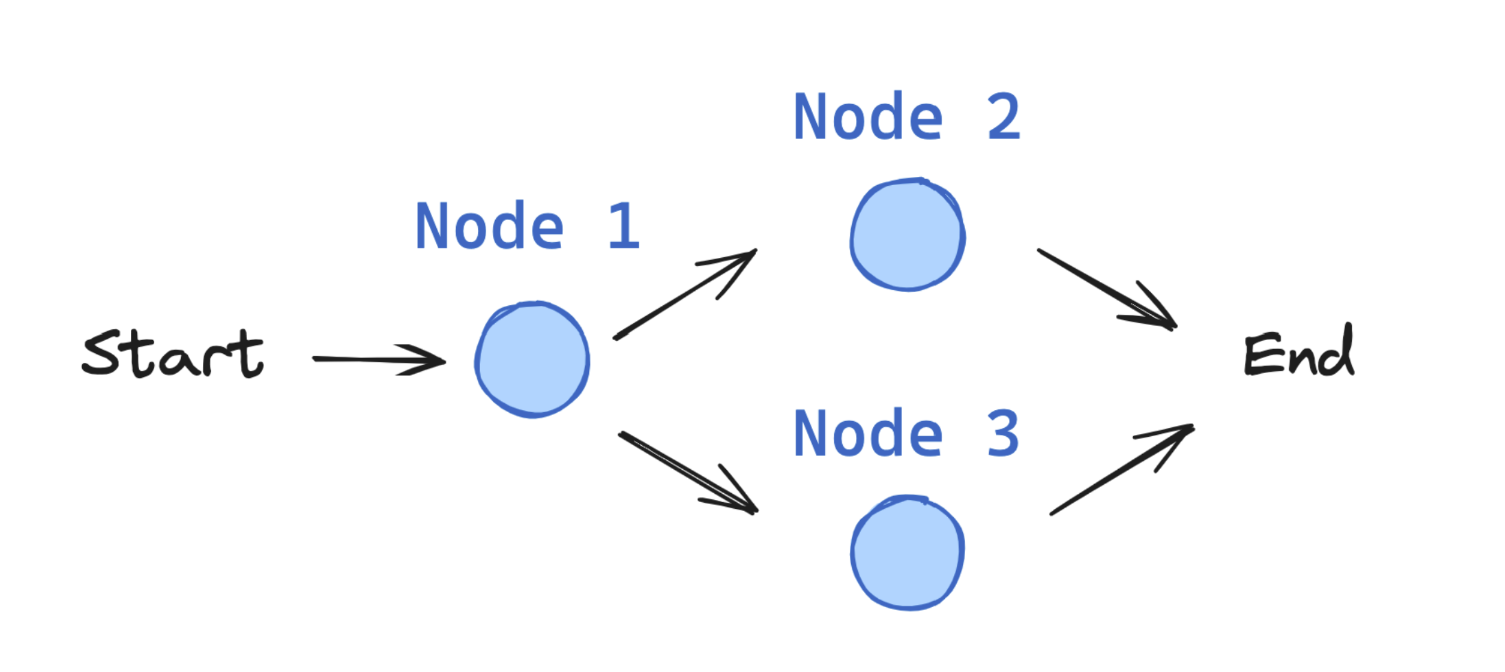

1. 상태(State)  
- `상태(State)`는 LangGraph의 중심 개념이며, 애플리케이션을 통해 흐르는 모든 정보를 나타냅니다.
- 상태는 사용자 정의이므로, 의사결정 과정에 필요한 모든 데이터를 포함하도록 신중하게 설계해야 합니다.
  - `|TIP|`: 애플리케이션이 단계 간에 추적해야할 정보가 무엇인지 신중하게 고민할 것

In [1]:
from typing_extensions import TypedDict

class State(TypedDict):
    graph_state: str

2. 노드(NODE)
- `노드(Node)`는 파이썬 함수입니다. 각 노드는, 
  - 상태를 입력으로 받습니다
  - 작업을 수행합니다
  - 상태 업데이트를 반환합니다


- 예를 들어, 노드는 다음과 같은 역할을 할 수 있습니다:
  - LLM 호출: 텍스트 생성 또는 의사결정
  - 도구 호출: 외부 시스템과 상호작용
  - 조건부 로직: 다음 단계 결정
  - 사람 개입: 사용자 입력 받기
- `|INFO|`: START와 END처럼 전체 워크플로우에 필수적인 일부 노드는 LangGraph에서 직접 제공합니다

In [2]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

3. 엣지(EDGE)
- 엣지(Edge)는 노드를 연결하며, 그래프 내에서 가능한 경로를 정의합니다.
- 엣지는 다음과 같이 나뉩니다:
  - 직접(Direct): 항상 노드A에서 노드B로 이동
  - 조건부(Conditional): 현재 상태에 따라 다음 노드를 선택

In [3]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # 종종 상태를 사용해 다음에 방문할 노드를 결정합니다
    user_input = state['graph_state'] 
    
    # 여기서는 노드 2, 3 사이를 50:50으로 분기합니다
    if random.random() < 0.5:

        # 50% 확률로 Node 2 반환
        return "node_2"
    
    # 50% 확률로 Node 3 반환
    return "node_3"

4. StageGraph
- `StateGraph`는 전체 에이전트 워크플로우를 담는 컨테이너입니다

In [4]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

# 그래프 생성
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# 로직 정의
builder.add_edge(START, "node_1")
builder.add_conditional_edges("node_1", decide_mood)
builder.add_edge("node_2", END)
builder.add_edge("node_3", END)

# 그래프 컴파일
graph = builder.compile()

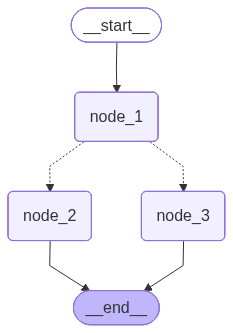

In [5]:
# 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 3---


{'graph_state': 'Hi, this is Lance. I am sad!'}

In [10]:
graph.invoke({"graph_state" : "Hi, this is Lance."})

---Node 1---
---Node 2---


{'graph_state': 'Hi, this is Lance. I am happy!'}